**Autenticación con hash y sal**

In [ ]:
import hashlib
import secrets

# Simulación de la base de datos en memoria
base_de_datos = {}

def generar_sal():
    """Genera una sal aleatoria y segura en formato hexadecimal."""
    return secrets.token_hex(16)

def calcular_hash_con_sal(password, sal):
    """Junta la contraseña con la sal y obtiene el hash SHA-256."""
    texto_combinado = password + sal
    return hashlib.sha256(texto_combinado.encode('utf-8')).hexdigest()

def registrar_usuario(usuario, password):
    """Registra un nuevo usuario generando su sal y guardando su hash."""
    if usuario in base_de_datos:
        print(f"[-] Error: El usuario '{usuario}' ya existe.")
        return

    # 1. Generar sal única
    sal = generar_sal()

    # 2. Calcular hash con sal
    hash_seguro = calcular_hash_con_sal(password, sal)

    # 3. Guardar en la base de datos
    base_de_datos[usuario] = {'sal': sal,'hash': hash_seguro}
    print(f"Usuario '{usuario}' registrado con éxito.")
    print(f"    -> Sal asignada: {sal}")
    print(f"    -> Hash guardado: {hash_seguro}\n")

def iniciar_sesion(usuario, password_ingresada):
    """Verifica si la contraseña ingresada coincide con la guardada."""
    if usuario not in base_de_datos:
        print(f"Acceso denegado: El usuario '{usuario}' no existe.\n")
        return False

    # 1. Recuperar la sal y el hash guardado de ese usuario
    sal_guardada = base_de_datos[usuario]['sal']
    hash_guardado = base_de_datos[usuario]['hash']

    # 2. Calcular el hash de la contraseña ingresada usando la misma sal
    hash_a_probar = calcular_hash_con_sal(password_ingresada, sal_guardada)

    # 3. Comparar hashes
    if hash_a_probar == hash_guardado:
        print(f"¡Bienvenido, {usuario}! Inicio de sesión exitoso.\n")
        return True
    else:
        print("Acceso denegado: Contraseña incorrecta.\n")
        return False

# --- Demostración práctica ---
if __name__ == "__main__":
    print("1. REGISTRO DE USUARIOS")
    # Dos usuarios usan LA MISMA contraseña para ver cómo la sal produce hashes distintos
    registrar_usuario("juan", "miclave1234")
    registrar_usuario("ana", "miclave1234")

    print("2. PRUEBA DE INICIO DE SESIÓN")
    # Intento con contraseña correcta
    iniciar_sesion("juan", "miclave1234")

    # Intento con contraseña incorrecta
    iniciar_sesion("ana", "miclave")

1. REGISTRO DE USUARIOS
Usuario 'juan' registrado con éxito.
    -> Sal asignada: 22badaea4818dee2e512b766ce586666
    -> Hash guardado: 3afc758e27343520a73a4e90285f2c1c40cea966ebf784162b6da7b4881b3fbc

Usuario 'ana' registrado con éxito.
    -> Sal asignada: 7706f81bec74163ace33c09936a954db
    -> Hash guardado: cd57165b6b59826c0ce33b6d7d447f018a4dbc88e2f36e73538987c393857b9f

2. PRUEBA DE INICIO DE SESIÓN
¡Bienvenido, juan! Inicio de sesión exitoso.

Acceso denegado: Contraseña incorrecta.



**Firma digital con RSA**

In [ ]:
!pip install cryptography

In [ ]:
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.exceptions import InvalidSignature

# Generar un par de claves RSA
private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048
)
public_key = private_key.public_key()

#clave privada a formato PEM
private_pem = private_key.private_bytes(
    encoding=serialization.Encoding.PEM,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

with open('clavePrivada.pem', 'wb') as archivo:
    archivo.write(private_pem)

#clave pública a formato PEM
public_pem = public_key.public_bytes(
    encoding=serialization.Encoding.PEM,
    format=serialization.PublicFormat.SubjectPublicKeyInfo
)

with open('clavePublica.pem', 'wb') as archivo:
    archivo.write(public_pem)

print("Claves generadas con exito")
print("Clave privada: clavePrivada.pem")
print("Clave publica: clavePublica.pem")

Claves generadas con exito
Clave privada: clavePrivada.pem
Clave publica: clavePublica.pem


In [ ]:
archivo_clasificado = "Mensaje_Con_Firma.txt"

#leer archivo en modo binario
with open(archivo_clasificado, 'rb') as archivo:
    mensaje_clasificado = archivo.read()

#firmar el archivo
firma = private_key.sign(
    mensaje_clasificado,
    padding.PSS(
        mgf=padding.MGF1(hashes.SHA256()),
        salt_length=padding.PSS.MAX_LENGTH
    ),
    hashes.SHA256()
)

#guaradar firma en archivo .bin
with open('firma.bin', 'wb') as archivo:
    archivo.write(firma)

print("Firma generada con exito")
print("Firma: firma.bin")

Firma generada con exito
Firma: firma.bin


In [ ]:
#verificasr firma del archivo
with open('Mensaje_Con_Firma.txt', 'rb') as archivo:
    datos_verificar = archivo.read()
with open('firma.bin', 'rb') as archivo:
    firma_comprobar = archivo.read()

try:
  public_key.verify(
      firma_comprobar,
      datos_verificar,
      padding.PSS(
          mgf=padding.MGF1(hashes.SHA256()),
          salt_length=padding.PSS.MAX_LENGTH
      ),
      hashes.SHA256()
  )
  print("Firma verificada con exito")
except InvalidSignature:
  print("Firma invalida")

Firma verificada con exito


In [ ]:
#ver archivp
with open('Mensaje_Con_Firma.txt', 'r', encoding="utf-8") as archivo:
    contenido = archivo.read()
    print(contenido)

#cargar calve publica
with open('clavePublica.pem', 'rb') as archivo:
    clave_publica = serialization.load_pem_public_key(archivo.read())

#leer bytes del doc y la fimra
with open('Mensaje_Con_Firma.txt', 'rb') as archivo:
    datos_verificar = archivo.read()
with open('firma.bin', 'rb') as archivo:
    firma_comprobar = archivo.read()

#vewrificar autenticidad
try:
  clave_publica.verify(
      firma_comprobar,
      datos_verificar,
      padding.PSS(
          mgf=padding.MGF1(hashes.SHA256()),
          salt_length=padding.PSS.MAX_LENGTH
      ),
      hashes.SHA256()
  )
  print("Firma verificada con exito")
except InvalidSignature:
  print("Firma invalida")

Como esta profe? si va a comprar el gta vi?
y usted que team es? team L o team Kira?dfsdfsdfdsf
Firma verificada con exito


**HASH y HMAC**

In [ ]:
#Hash de Texto
texto_a = "Mensaje confidencial 1"
texto_b = "Mensaje confidencial 2"  #solo cambia el último número

hash_a = hashlib.sha256(texto_a.encode('utf-8')).hexdigest()
hash_b = hashlib.sha256(texto_b.encode('utf-8')).hexdigest()

print("1. SHA-256 EN TEXTO (EFECTO AVALANCHA)")
print(f"Texto A: {texto_a} -> Hash: {hash_a}")
print(f"Texto B: {texto_b} -> Hash: {hash_b}\n")

#Hash de un Archivo/
#se crea un archivo de prueba
with open("archivo_prueba.txt", "w", encoding="utf-8") as f:
    f.write("Contenido original del archivo para hash.")

def calcular_hash_archivo(ruta_archivo):
    """Lee un archivo en bloques binarios para calcular su SHA-256 de forma eficiente."""
    sha256 = hashlib.sha256()
    with open(ruta_archivo, "rb") as f:
        while chunk := f.read(4096):
            sha256.update(chunk)
    return sha256.hexdigest()

print("2. HASH DE ARCHIVO")
print(f"Hash de 'archivo_prueba.txt': {calcular_hash_archivo('archivo_prueba.txt')}\n")

1. SHA-256 EN TEXTO (EFECTO AVALANCHA)
Texto A: Mensaje confidencial 1 -> Hash: 814820f2d23cba4d774ca6a89f5dafc53ded0412cfd61dfd3560ae95eea4c400
Texto B: Mensaje confidencial 2 -> Hash: 1267324d12d90c0c9f503c4c6a2fdb2e4780a2e52dd804bd785089ebdec4eb36

2. HASH DE ARCHIVO
Hash de 'archivo_prueba.txt': cb4ab7c011a9c9bcf0f8e0fb2cc9e2fbbeea54fdb173f165cc05befc32170178



In [ ]:
# Creamos dos archivos: uno idéntico y uno modificado
with open("archivo_copia.txt", "w", encoding="utf-8") as f:
    f.write("Contenido original del archivo para hash.")

with open("archivo_modificado.txt", "w", encoding="utf-8") as f:
    f.write("Contenido alterado del archivo.")

def comparar_integridad(archivo_1, archivo_2):
    """Compara el hash SHA-256 de dos archivos para validar su integridad."""
    hash_1 = calcular_hash_archivo(archivo_1)
    hash_2 = calcular_hash_archivo(archivo_2)

    print(f"Hash Archivo 1 ({archivo_1}): {hash_1}")
    print(f"Hash Archivo 2 ({archivo_2}): {hash_2}")

    if hash_1 == hash_2:
        print("Los archivos son IDÉNTICOS (Integridad confirmada).\n")
        return True
    else:
        print("Los archivos son DIFERENTES (Integridad comprometida).\n")
        return False

print("3. COMPARACIÓN DE INTEGRIDAD")
print("Comparando archivo original vs copia exacta")
comparar_integridad("archivo_prueba.txt", "archivo_copia.txt")

print("Comparando archivo original vs archivo alterado")
comparar_integridad("archivo_prueba.txt", "archivo_modificado.txt")

3. COMPARACIÓN DE INTEGRIDAD
Comparando archivo original vs copia exacta
Hash Archivo 1 (archivo_prueba.txt): cb4ab7c011a9c9bcf0f8e0fb2cc9e2fbbeea54fdb173f165cc05befc32170178
Hash Archivo 2 (archivo_copia.txt): cb4ab7c011a9c9bcf0f8e0fb2cc9e2fbbeea54fdb173f165cc05befc32170178
Los archivos son IDÉNTICOS (Integridad confirmada).

Comparando archivo original vs archivo alterado
Hash Archivo 1 (archivo_prueba.txt): cb4ab7c011a9c9bcf0f8e0fb2cc9e2fbbeea54fdb173f165cc05befc32170178
Hash Archivo 2 (archivo_modificado.txt): e9df3280e58c931a8254ba092ab1fae4f36bf2389c91e536ea13eb817bb2266b
Los archivos son DIFERENTES (Integridad comprometida).



False

In [ ]:
import hmac

# Clave secreta conocida únicamente por el emisor y el receptor
CLAVE_SECRETA = b"clave_secreta_super_segura_2026"

def generar_hmac(mensaje_bytes, clave):
    """Genera un código HMAC-SHA256 para un mensaje dado."""
    return hmac.new(clave, mensaje_bytes, hashlib.sha256).hexdigest()

def verificar_hmac(mensaje_bytes, clave, hmac_recibido):
    """Verifica si el HMAC recibido coincide de forma segura contra tiempos de ataque."""
    hmac_calculado = generar_hmac(mensaje_bytes, clave)
    # compare_digest previene ataques de temporización (timing attacks)
    return hmac.compare_digest(hmac_calculado, hmac_recibido)

# --- Demostración práctica ---
print("4. GENERACIÓN Y VERIFICACIÓN DE HMAC")
mensaje = b"Transferir $500.000 a la cuenta 8841-23"
codigo_hmac = generar_hmac(mensaje, CLAVE_SECRETA)

print(f"Mensaje: {mensaje.decode()}")
print(f"HMAC Generado: {codigo_hmac}\n")

# Prueba 1: Verificación exitosa
es_valido = verificar_hmac(mensaje, CLAVE_SECRETA, codigo_hmac)
print(f"1. Verificación mensaje original: {'VALIDO' if es_valido else 'INVALIDO'}")

# Prueba 2: Mensaje alterado por un atacante en el canal
mensaje_interceptado = b"Transferir $900.000 a la cuenta 8841-23"
es_valido_alterado = verificar_hmac(mensaje_interceptado, CLAVE_SECRETA, codigo_hmac)
print(f"2. Verificación mensaje alterado: {'VALIDO' if es_valido_alterado else 'ALERTA: MANIPULACION DETECTADA'}")

# Prueba 3: Mensaje legítimo pero verificado con clave errónea
es_valido_clave_falsa = verificar_hmac(mensaje, b"clave_falsa_123", codigo_hmac)
print(f"3. Verificación con clave errónea: {'VALIDO' if es_valido_clave_falsa else 'ALERTA: AUTOR NO AUTENTICADO'}")

4. GENERACIÓN Y VERIFICACIÓN DE HMAC
Mensaje: Transferir $500.000 a la cuenta 8841-23
HMAC Generado: 1a26f191944c024ae07ab5b4ba306eeaf59799baf1f8d670946cc1a614da3a30

1. Verificación mensaje original: VALIDO
2. Verificación mensaje alterado: ALERTA: MANIPULACION DETECTADA
3. Verificación con clave errónea: ALERTA: AUTOR NO AUTENTICADO


**Laboratorio VPN y HTTPS**

**Captura sin VPN**

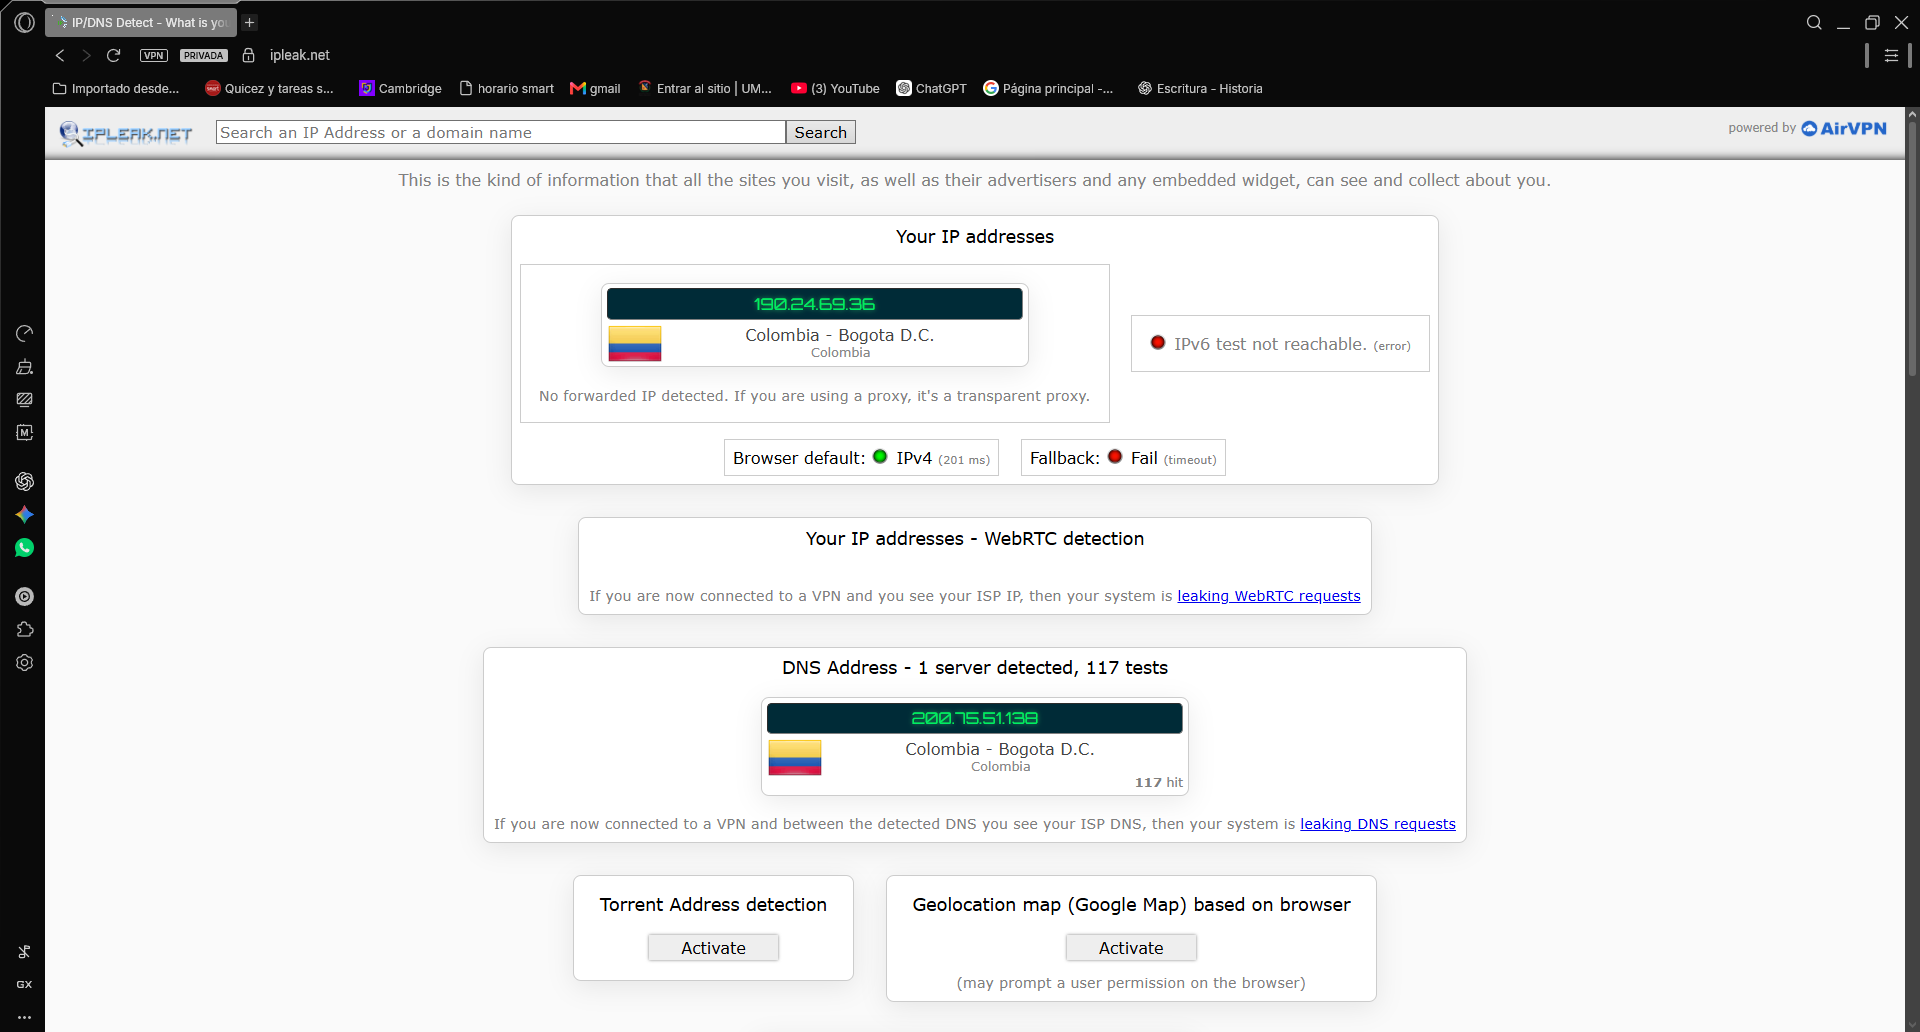

**Captura con VPN de Opera activa**

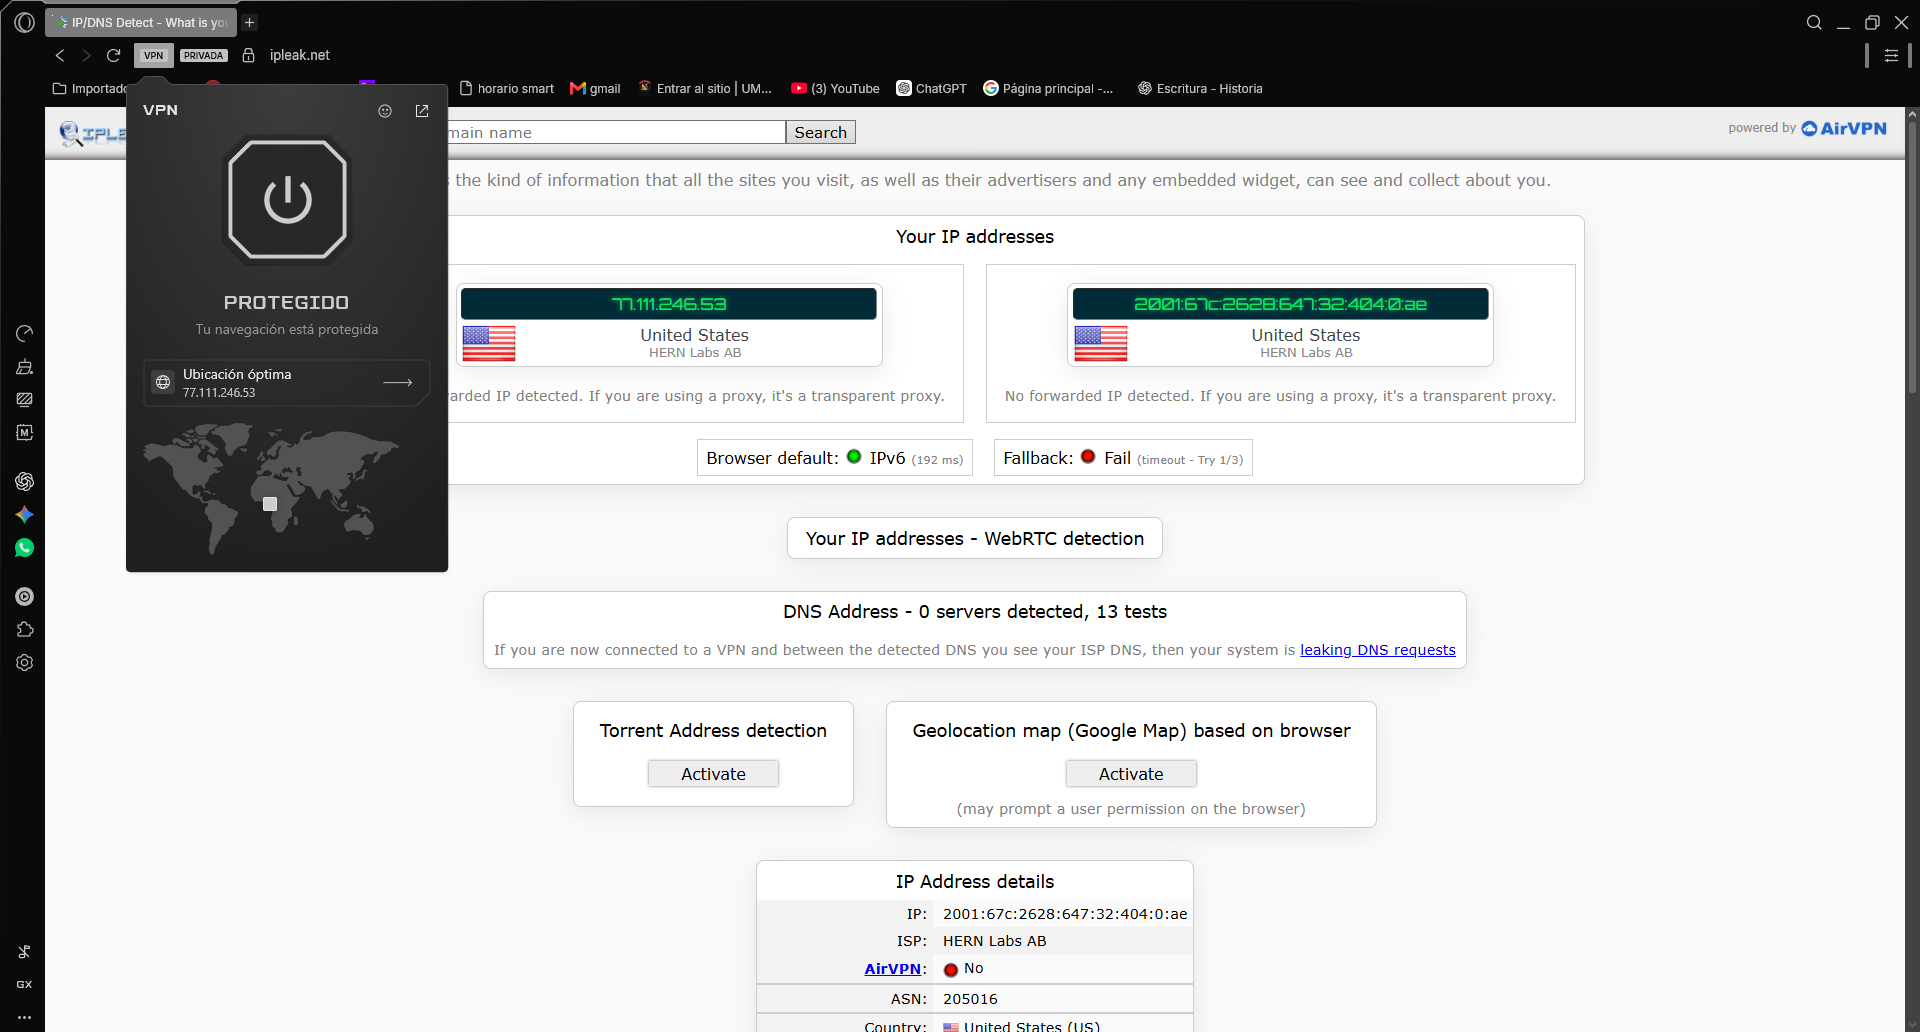

**1. ¿Qué cambió entre ambas conexiones?**



*   **Enmascaramiento de Identidad:** La dirección IP pública cambió de Colombia a Estados Unidos, ocultando la ubicación física y el proveedor de servicios de internet real ante cualquier servidor externo.
*   **Resolución de Nombres Protegida (DNS Leak Prevention):** En la conexión normal, las consultas de navegación pasaban directamente por los servidores DNS locales (200.75.51.138). Con la VPN activa, las solicitudes se resuelven dentro del propio túnel cifrado, evitando que terceros sepan qué dominios web estás consultando.  

**2. ¿Qué protege y qué no protege la VPN?**

**Lo que sí protege:**

Convierte toda la actividad de internet en un código secreto desde el computador hasta el servidor VPN. De esta forma, si está conectado a un Wi-Fi público o ante una empresa proveedora de internet, nadie puede espiar, leer ni entender lo que está haciendo en línea.

Oculta la huella geográfica y dirección IP ante los sitios web visitados.

**Lo que no protege:**

No evita el rastreo si se inicia sesión en plataformas como Google o redes sociales (seguimiento por cookies/cuentas).

No es un antivirus: no bloquea archivos maliciosos descargados ni ataques de ingeniería social (phishing).

In [ ]:
import requests

# 1. Petición HTTP (Texto plano, sin cifrado)
url_http = "http://httpbin.org/get"
respuesta_http = requests.get(url_http)

print("=== 1. TRÁFICO HTTP (NO SEGURO) ===")
print(f"URL: {url_http}")
print(f"Estado HTTP: {respuesta_http.status_code}")
print(f"Esquema seguro: {respuesta_http.url.startswith('https')}")
print(f"Encabezados recibidos:")
for clave, valor in list(respuesta_http.headers.items())[:4]:
    print(f"  -> {clave}: {valor}")
print("-" * 50)

# 2. Petición HTTPS (Cifrado TLS en tránsito)
url_https = "https://httpbin.org/get"
respuesta_https = requests.get(url_https)

print("=== 2. TRÁFICO HTTPS (SEGURO / TLS) ===")
print(f"URL: {url_https}")
print(f"Estado HTTP: {respuesta_https.status_code}")
print(f"Esquema seguro: {respuesta_https.url.startswith('https')}")
print(f"Encabezados de seguridad:")
for clave, valor in list(respuesta_https.headers.items())[:4]:
    print(f"  -> {clave}: {valor}")
print("-" * 50)

=== 1. TRÁFICO HTTP (NO SEGURO) ===
URL: http://httpbin.org/get
Estado HTTP: 200
Esquema seguro: False
Encabezados recibidos:
  -> Date: Sat, 22 Aug 2026 20:22:33 GMT
  -> Content-Type: application/json
  -> Content-Length: 317
  -> Connection: keep-alive
--------------------------------------------------
=== 2. TRÁFICO HTTPS (SEGURO / TLS) ===
URL: https://httpbin.org/get
Estado HTTP: 200
Esquema seguro: True
Encabezados de seguridad:
  -> Date: Sat, 22 Aug 2026 20:22:33 GMT
  -> Content-Type: application/json
  -> Content-Length: 318
  -> Connection: keep-alive
--------------------------------------------------


In [ ]:
# 3. Comprobación de errores SSL / Certificados Inválidos
url_insegura_ssl = "https://expired.badssl.com/"

print("=== 3. PRUEBA DE CERTIFICADO SSL EXPIRADO ===")
try:
    print(f"Intentando conectar a: {url_insegura_ssl}")
    # requests valida certificados SSL por defecto (verify=True)
    requests.get(url_insegura_ssl)
except requests.exceptions.SSLError as error_ssl:
    print("[!] ALERTA: La conexión fue bloqueada por fallo en el certificado TLS/SSL.")
    print(f"    Detalle del error: {error_ssl}\n")

# 4. Inspección profunda del certificado SSL/TLS con socket y ssl
import socket
import ssl
from pprint import pprint

def inspeccionar_certificado(host, puerto=443):
    contexto = ssl.create_default_context()
    with socket.create_connection((host, puerto)) as sock:
        with contexto.wrap_socket(sock, server_hostname=host) as ssock:
            certificado = ssock.getpeercert()
            print(f"=== 4. CERTIFICADO TLS VÁLIDO PARA: {host} ===")
            print(f"Sujeto (Dominio): {certificado.get('subject')}")
            print(f"Emisor (Autoridad Certificadora CA): {certificado.get('issuer')}")
            print(f"Válido desde: {certificado.get('notBefore')}")
            print(f"Válido hasta: {certificado.get('notAfter')}")
            print(f"Versión TLS negociada: {ssock.version()}")

inspeccionar_certificado("www.google.com")

=== 3. PRUEBA DE CERTIFICADO SSL EXPIRADO ===
Intentando conectar a: https://expired.badssl.com/
[!] ALERTA: La conexión fue bloqueada por fallo en el certificado TLS/SSL.
    Detalle del error: HTTPSConnectionPool(host='expired.badssl.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1032)')))

=== 4. CERTIFICADO TLS VÁLIDO PARA: www.google.com ===
Sujeto (Dominio): ((('commonName', 'www.google.com'),),)
Emisor (Autoridad Certificadora CA): ((('countryName', 'US'),), (('organizationName', 'Google Trust Services'),), (('commonName', 'WR2'),))
Válido desde: Aug  5 20:44:34 2026 GMT
Válido hasta: Oct 28 20:44:33 2026 GMT
Versión TLS negociada: TLSv1.3
